# Image Recognition Masterclass: CNNs for Dermatological Classification

Welcome. In this notebook, we're building a convolutional neural network from first principles, using it to classify skin condition images from the Dermnet dataset, and then taking it further with transfer learning and fine-tuning — the same progression you'd follow on a real applied ML project.

My goal isn't just to get you a working model by the end of this notebook. It's to build the judgment behind each decision: why we choose a particular architecture, why data leakage between validation and test sets quietly invalidates your metrics, and why a model that looks great on paper still needs real-world scrutiny before it goes near a clinical setting. Throughout the notebook you'll see **"In the Real World"** callouts — these mark places where a production system would need to go further than a teaching demo, and I've built several of those improvements directly into the code so you can see the difference in practice.

**Roadmap:**
1.  **Data Acquisition** — pulling the Dermnet dataset from Kaggle
2.  **Data Exploration & Preprocessing** — understanding what we're working with, including a note on the ethical dimension of medical image data
3.  **CNN Fundamentals** — convolution, padding, stride, and pooling, worked by hand before we let a framework do it for us
4.  **Building and Training a Baseline CNN** — a simple architecture, trained honestly, to establish a starting point
5.  **Model Evaluation & Interpretation** — reading training curves and metrics like a practitioner, not just glancing at a final accuracy number
6.  **From Baseline to Production** — transfer learning, fine-tuning, class imbalance handling, and the training infrastructure (callbacks, proper validation splits) a real deployment would require
7.  **Responsible Deployment** — confusion matrix diagnostics, model saving, and what would still need to happen before this touches a real patient

Let's get started.

### Before We Touch Any Data: Reproducibility & Environment

Two habits I want you to build before writing a single line of data-loading code: **fix your random seeds**, and **confirm what hardware you're running on**. Neither is exciting, but skipping them is how teams end up debugging "why did my number change between runs" issues that have nothing to do with the model itself, or training a CNN on CPU for six hours by accident because nobody checked the Colab runtime type. Two minutes now saves a lot of confusion later.

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

# Fixing seeds across every source of randomness (Python's own RNG, NumPy, and
# TensorFlow) doesn't make training fully deterministic on GPU -- cuDNN has some
# non-deterministic ops -- but it removes most run-to-run variance, which matters
# a lot when you're teaching and want the class to see comparable results.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU available: {gpu_devices[0].name} — good, training will be fast.")
else:
    print(
        "No GPU detected. In Colab: Runtime > Change runtime type > select a GPU "
        "hardware accelerator. Training the CNNs in this notebook on CPU will be "
        "painfully slow, especially the transfer learning section."
    )

TensorFlow version: 2.20.0
GPU available: /physical_device:GPU:0 — good, training will be fast.


## 1. Data Acquisition

We're using the [Dermnet dataset](https://www.kaggle.com/datasets/shubhamgoel27/dermnet) from Kaggle: tens of thousands of clinical images spanning roughly two dozen categories of skin conditions, pre-split into training and test folders. Getting it into this Colab environment takes three steps — authenticate with Kaggle, download, and unzip.

In [2]:
# First, let's make sure we have the `kaggle` library installed. This will allow us to easily download the dataset directly from Kaggle.
!pip install kaggle

### Securing Your Kaggle Credentials

To download the dataset, you need to authenticate with Kaggle:

1.  **Go to Kaggle** and log in.
2.  **Open your profile** → **Account** tab.
3.  **Create New API Token** — this downloads a `kaggle.json` file containing your username and key.

**In the real world**, don't re-upload that file (or worse, paste your key directly into a cell) every time you open this notebook — treat an API key the way you'd treat a password. The code below checks **Colab Secrets** first (the key icon in the left sidebar — add `KAGGLE_USERNAME` and `KAGGLE_KEY` there once) and only falls back to a manual upload prompt if secrets aren't set up. This is a small thing, but it's exactly the kind of habit that separates a notebook you'd show in a demo from one you'd actually trust running unattended.

In [3]:
# import os

# os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# try:
#     # Preferred path: credentials stored once in Colab Secrets.
#     from google.colab import userdata
#     kaggle_username = userdata.get('KAGGLE_USERNAME')
#     kaggle_key = userdata.get('KAGGLE_KEY')
#     if not kaggle_username or not kaggle_key:
#         raise ValueError("Secrets not set")
#     with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
#         f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')
#     print("Kaggle credentials loaded from Colab Secrets.")
# except Exception:
#     # Fallback: manual upload, for anyone who hasn't set up Secrets yet.
#     from google.colab import files
#     print("Colab Secrets not found for KAGGLE_USERNAME/KAGGLE_KEY.")
#     print("Please upload your kaggle.json file now.")
#     files.upload()
#     !mv kaggle.json ~/.kaggle/

# !chmod 600 ~/.kaggle/kaggle.json
# print("Kaggle API key configured!")

Colab Secrets not found for KAGGLE_USERNAME/KAGGLE_KEY.
Please upload your kaggle.json file now.


mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key configured!


### Downloading the Dermnet Dataset

With authentication sorted, we can pull the dataset straight from Kaggle's CLI. This is a few hundred MB, so expect this to take a minute or two on a typical Colab connection.

In [4]:
# Let's download the dataset. This might take a few minutes depending on your connection.
!kaggle datasets download -d shubhamgoel27/dermnet

print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/shubhamgoel27/dermnet
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 1.72G/1.72G [00:29<00:00, 62.5MB/s]

Dataset downloaded!


### Unzipping the Dataset

The download arrives as a single zip archive. We'll extract it into its own directory so it doesn't clutter the Colab workspace, and so the path structure stays predictable for everything that follows.

In [5]:
import zipfile
import os

dataset_path = 'dermnet.zip'
extraction_path = 'dermnet_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Dataset unzipped to: {extraction_path}")

# Let's quickly check what's inside the extracted folder
!ls {extraction_path}

Dataset unzipped to: dermnet_data
test  train


In [6]:
import os

train_dir = os.path.join('dermnet_data', 'train')
test_dir = os.path.join('dermnet_data', 'test')

# Let's count the number of classes and images
num_train_classes = len(os.listdir(train_dir))
num_test_classes = len(os.listdir(test_dir))

print(f"Number of training classes: {num_train_classes}")
print(f"Number of testing classes: {num_test_classes}")

# Now, let's count the total number of images in each set
total_train_images = sum([len(files) for r, d, files in os.walk(train_dir)])
total_test_images = sum([len(files) for r, d, files in os.walk(test_dir)])

print(f"Total training images: {total_train_images}")
print(f"Total testing images: {total_test_images}")

# Let's also peek into the class names
print("\nSample training class names:")
print(os.listdir(train_dir)[:5]) # Display first 5 class names

Number of training classes: 23
Number of testing classes: 23
Total training images: 15557
Total testing images: 4002

Sample training class names:
['Herpes HPV and other STDs Photos', 'Melanoma Skin Cancer Nevi and Moles', 'Exanthems and Drug Eruptions', 'Cellulitis Impetigo and other Bacterial Infections', 'Hair Loss Photos Alopecia and other Hair Diseases']


## 2. Data Exploration & Preprocessing

Before writing a single line of model code, we need to understand what we're actually working with. Skipping this step is one of the most common mistakes I see even from experienced engineers moving into ML for the first time — you cannot make good modeling decisions about data you haven't looked at. We'll examine:

*   **Dataset structure** — how the images are organized on disk
*   **Class distribution** — whether the conditions are represented evenly, and what that means for training
*   **Image characteristics** — what the images actually look like, and where the real-world messiness lives
*   **Data augmentation strategy** — how we'll responsibly expand a limited training set

Let's start with the basic shape of the data: how many classes, how many images per split.

### Reading the Initial Scan

The class and image counts above tell us the dataset's scale, and the matching class count between train and test is a good sanity check — it confirms the split wasn't done carelessly (e.g., a class present in training but entirely absent from test). What it doesn't tell us yet is whether those classes are represented *evenly*. That's the more important question, and it's next.

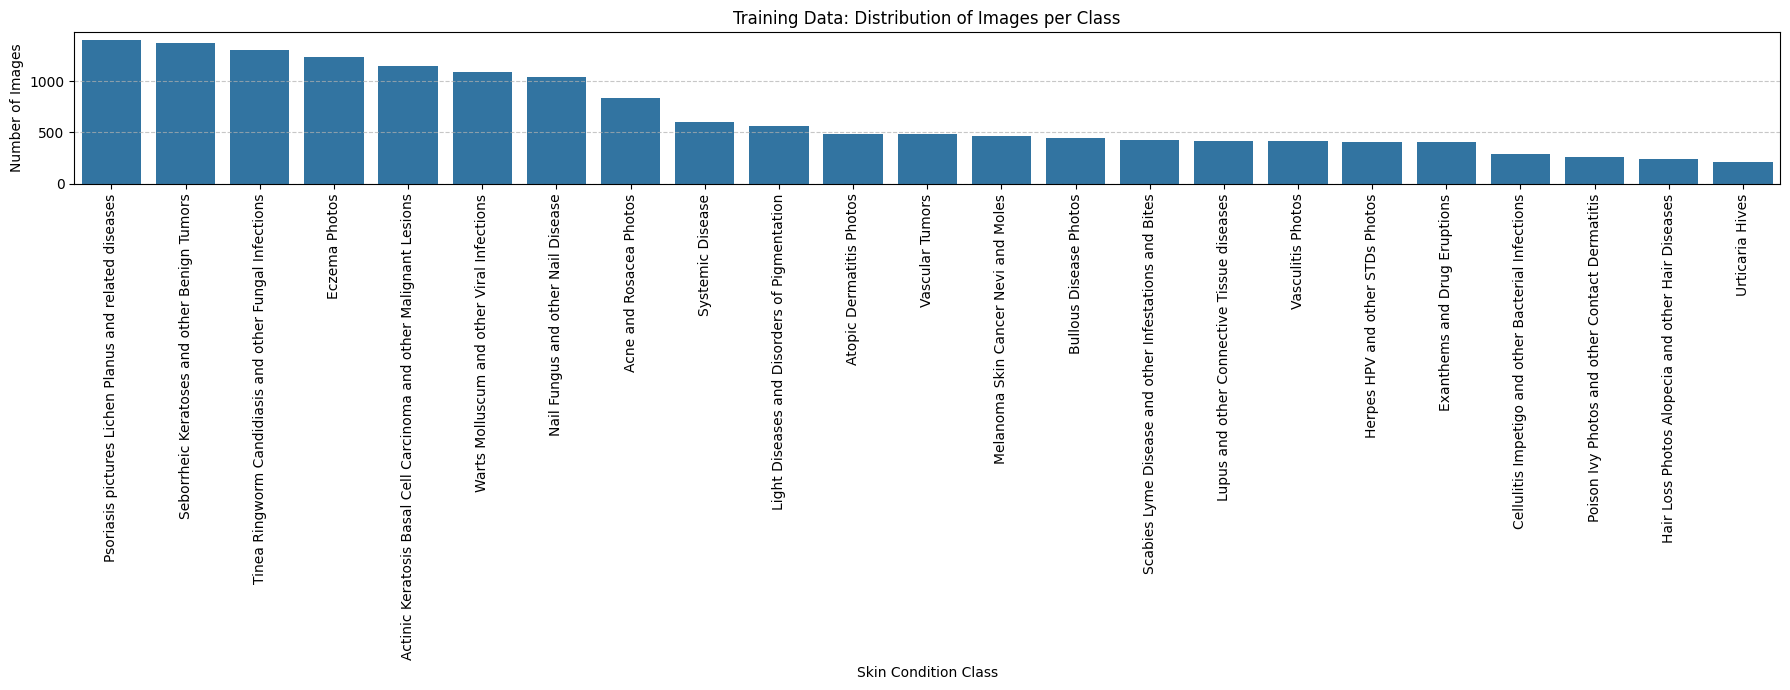


Top 10 most common training classes:
                                                             Class  Count
             Psoriasis pictures Lichen Planus and related diseases   1405
                      Seborrheic Keratoses and other Benign Tumors   1371
            Tinea Ringworm Candidiasis and other Fungal Infections   1300
                                                     Eczema Photos   1235
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions   1149
                        Warts Molluscum and other Viral Infections   1086
                                Nail Fungus and other Nail Disease   1040
                                           Acne and Rosacea Photos    840
                                                  Systemic Disease    606
                      Light Diseases and Disorders of Pigmentation    568

Top 10 least common training classes:
                                                Class  Count
                                      Urticaria 

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Function to count images per class
def count_images_per_class(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

train_class_counts = count_images_per_class(train_dir)
test_class_counts = count_images_per_class(test_dir)

# Convert to DataFrame for easier plotting
train_df = pd.DataFrame(list(train_class_counts.items()), columns=['Class', 'Count'])
test_df = pd.DataFrame(list(test_class_counts.items()), columns=['Class', 'Count'])

# Plotting the distribution for training set
plt.figure(figsize=(18, 7))
sns.barplot(x='Class', y='Count', data=train_df.sort_values('Count', ascending=False))
plt.xticks(rotation=90)
plt.title('Training Data: Distribution of Images per Class')
plt.xlabel('Skin Condition Class')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 10 most common training classes:")
print(train_df.sort_values('Count', ascending=False).head(10).to_string(index=False))

print("\nTop 10 least common training classes:")
print(train_df.sort_values('Count', ascending=True).head(10).to_string(index=False))

### Reading the Class Distribution

The bar chart makes it obvious: this is not a balanced dataset. Some conditions have several times more training images than others. Left unaddressed, this is exactly the kind of thing that produces a model with a deceptively high overall accuracy that's actually just defaulting to the majority classes — a serious problem in a diagnostic context, where the rare classes are often the ones you most need to catch.

There are a few standard responses to this:

*   **Data augmentation** for the minority classes specifically, not just the dataset as a whole
*   **Class weighting** during training, so the loss function penalizes mistakes on rare classes more heavily
*   **Stratified evaluation** — reporting per-class metrics, not just one aggregate number, so imbalance doesn't hide in an average

We'll come back to class weighting concretely once we move into transfer learning later in the notebook. For now, keep this imbalance in mind — it's going to explain some of the baseline model's weaker spots later on.

### Visualizing Sample Images

Numbers only tell part of the story. Let's actually look at some images — this is where you catch things a summary table never will: inconsistent lighting, cropping, image quality, or artifacts that a model will have to learn to see past.

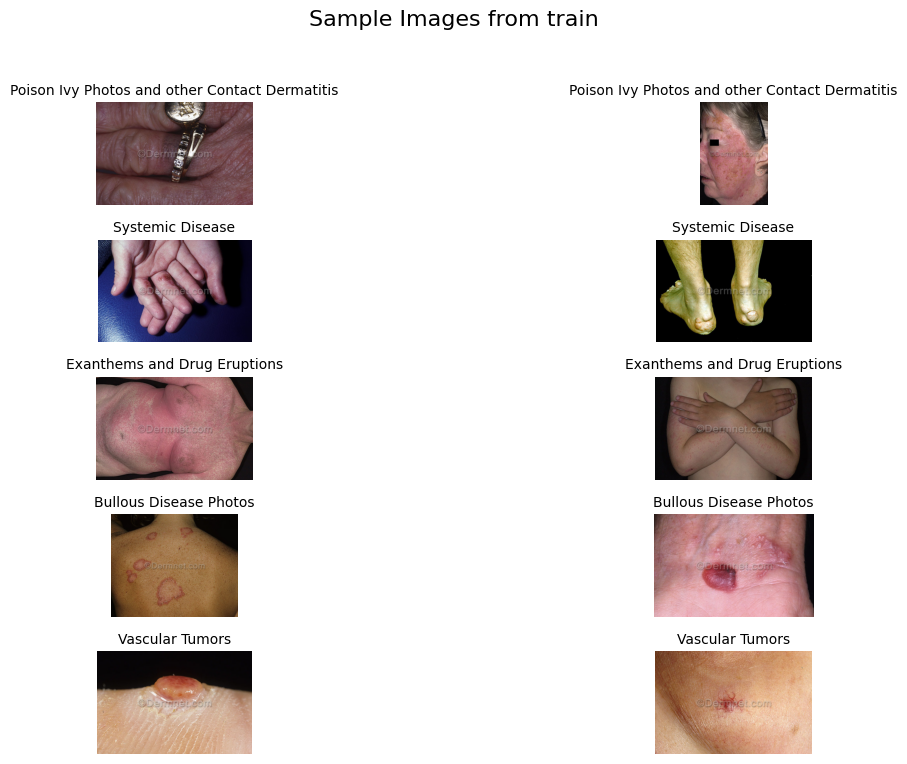

In [8]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import numpy as np

def display_sample_images(directory, num_images_per_class=2, num_classes_to_show=5):
    class_names = os.listdir(directory)
    random.shuffle(class_names) # Shuffle to get different classes each time

    fig = plt.figure(figsize=(15, 8))
    plt.suptitle(f'Sample Images from {os.path.basename(directory)}', fontsize=16)

    selected_classes = class_names[:num_classes_to_show]
    plot_idx = 1
    for class_name in selected_classes:
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            images_in_class = os.listdir(class_path)
            random.shuffle(images_in_class)

            for i in range(min(num_images_per_class, len(images_in_class))):
                img_path = os.path.join(class_path, images_in_class[i])
                try:
                    img = Image.open(img_path)
                    ax = fig.add_subplot(num_classes_to_show, num_images_per_class, plot_idx)
                    ax.imshow(img)
                    ax.set_title(f'{class_name}', fontsize=10)
                    ax.axis('off')
                    plot_idx += 1
                except Exception as e:
                    print(f"Could not load image {img_path}: {e}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

# Display sample images from the training set
display_sample_images(train_dir)

### Reading the Sample Images

A few things worth noting from this grid:

*   **Visual variety within a class** — the same condition can look meaningfully different across patients, lighting conditions, and camera angles. That's real-world variability our model needs to learn to generalize across, not memorize around.
*   **Image quality is inconsistent** — resolution, framing, and lighting vary noticeably. In a real deployment, incoming images would be just as inconsistent (probably more so, coming from varied phone cameras), so this isn't a data cleaning problem we can wish away — it's a robustness requirement our augmentation strategy needs to account for.
*   **Some images are hard to interpret even for a human eye.** This matters: if a trained clinician would find some of these ambiguous, we shouldn't expect a model trained on them to be perfectly confident either, and we should design our evaluation to reflect that instead of expecting near-100% accuracy.

### A Trainer's Note: Responsible AI in Dermatological Imaging

I want to flag something explicitly here, because it's easy to skip past in a technical walkthrough: **this is medical image data, and that changes the stakes.**

A few things worth knowing before we go further, and worth internalizing as a habit for any project like this:

*   **Dataset bias is a well-documented issue in dermatology AI.** Publicly available skin condition datasets, including this one, have historically skewed toward lighter skin tones, which means a model trained on them can perform unevenly across skin tones it saw less of during training. That's not a hypothetical concern — it's been documented in peer-reviewed research on dermatology AI systems, and it's exactly the kind of failure mode that doesn't show up in an aggregate accuracy number.
*   **A public Kaggle dataset is not a clinically validated dataset.** We don't know the provenance, imaging protocols, or diagnostic confirmation process behind every image here. That's fine for a training exercise; it would not be fine for anything touching real patients.
*   **This notebook produces a decision-support prototype, not a diagnostic device.** Anything built here would need external validation on a demographically representative, prospectively collected dataset, clinician-in-the-loop review, and (in most jurisdictions) regulatory clearance before it could ethically inform a real diagnosis.

I'll come back to this at the end of the notebook once we have a trained model to talk about concretely. For now, hold onto it as context for every modeling decision that follows — including the class-weighting and augmentation choices coming up next.

### Setting Up Image Data Generators

We can't load every image into memory at once — deep learning at this scale is built around loading data in batches. Keras's `ImageDataGenerator` handles that for us, and does three things simultaneously:

1.  **Streams images in batches** directly from disk, which keeps memory usage flat regardless of dataset size.
2.  **Standardizes** every image to a common size and pixel scale.
3.  **Augments** training images on the fly — small random rotations, shifts, zooms, and flips — which acts as a cheap way to expand a limited dataset and make the model less likely to memorize incidental details.

One structural decision here that I want to call out before you see the code: **we're carving a genuine validation set out of the training folder**, rather than reusing the test folder as validation during training (which is what an earlier draft of this notebook did, and what a lot of tutorials do without comment). I'll explain exactly why that matters in the takeaway after this cell — it's one of the more consequential fixes in this whole notebook.

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
IMG_HEIGHT = 224 # Common size for many pre-trained models
IMG_WIDTH = 224
BATCH_SIZE = 32

# --- IN THE REAL WORLD: a genuine three-way split ---
# Reusing the Dermnet 'test' folder as both the validation set (monitored every
# epoch, implicitly influencing early-stopping and checkpoint decisions) AND the
# final "held-out" test set is data leakage: once a set has influenced any
# training decision, it can no longer give an unbiased read on generalization.
# Here we carve a genuine validation split out of the TRAINING folder instead,
# and keep `test_dir` completely untouched until one final evaluation at the end.
VALIDATION_SPLIT = 0.15  # 15% of the training folder held back for validation

# Augmentation + rescaling for the training subset. This makes our model more
# robust to variations in the input data.
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Normalize pixel values to [0, 1]
    rotation_range=40,              # Randomly rotate images by up to 40 degrees
    width_shift_range=0.2,          # Randomly shift images horizontally
    height_shift_range=0.2,         # Randomly shift images vertically
    shear_range=0.2,                # Apply shear transformations
    zoom_range=0.2,                 # Randomly zoom into images
    horizontal_flip=True,           # Randomly flip images horizontally
    fill_mode='nearest',            # Fill in new pixels created by transformations
    validation_split=VALIDATION_SPLIT
)

# Validation data should NEVER be augmented -- we only rescale it, so validation
# metrics reflect performance on clean, realistic images, not distorted ones.
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

# The test set gets its own generator, pointed at test_dir, and is never passed
# into model.fit() as validation_data anywhere in this notebook.
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images (augmented) from the training subset
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Since we have multiple classes
    subset='training',
    seed=SEED
)

# Flow validation images (unaugmented) from the same training folder's held-out subset
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# Flow test images from the fully separate test directory
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle test data to maintain consistency for evaluation
)

print("Image Data Generators configured successfully!")
print(f"Found {train_generator.samples} training images belonging to {train_generator.num_classes} classes.")
print(f"Found {val_generator.samples} validation images (held out from the training folder).")
print(f"Found {test_generator.samples} test images (fully held out, used only for final evaluation).")

Found 13233 images belonging to 23 classes.
Found 2324 images belonging to 23 classes.
Found 4002 images belonging to 23 classes.
Image Data Generators configured successfully!
Found 13233 training images belonging to 23 classes.
Found 2324 validation images (held out from the training folder).
Found 4002 test images (fully held out, used only for final evaluation).


### Key Takeaway: Why the Three-Way Split Matters

Here's the issue with reusing a "test" set as validation during training, and it's subtle enough that it's worth spelling out: every time you check validation accuracy during training — to decide when to stop, which checkpoint to keep, or which hyperparameters worked — you are, even implicitly, letting that data influence your choices. Once that happens, that set can no longer tell you how the model performs on data it has *never* informed a decision about. Report a "test accuracy" from a set that was actually used this way, and you're reporting an optimistic number, not a true estimate of generalization.

The fix is what we just did: `val_generator` is drawn from the training folder and used for every epoch-by-epoch check during training. `test_generator`, pointed at the completely separate `test_dir`, is never passed to `model.fit()` anywhere in this notebook — it's touched exactly once, at the very end, for a single final evaluation. That's the discipline a real project needs to hold to for its reported metrics to mean anything.

A couple of other details worth noting:

*   **`val_generator` uses a separate, augmentation-free `ImageDataGenerator`.** Augmenting validation images would mean measuring performance on artificially distorted data, which isn't what we actually care about — we want to know how the model does on clean, realistic images.
*   **We resize everything to `224×224`** and normalize pixel values to `[0, 1]` — this size is chosen partly because it's the native input size for the pre-trained architectures (like MobileNetV2) we'll use later for transfer learning.

With our data properly and honestly split, we're ready for the conceptual core of this notebook: how a CNN actually processes an image.

## 3. CNN Fundamentals: The Building Blocks of Image Recognition

Before we let Keras build a model for us, I want you to see the arithmetic underneath it. It's the difference between being able to use a CNN and being able to reason about *why* it's misbehaving when it does. We'll build up, by hand with plain NumPy, the four operations that make up almost every CNN:

*   **Convolution** — the feature detector
*   **Padding** — how we control what happens at the image's edges
*   **Stride** — how far the detector moves each step
*   **Pooling** — how we downsample and keep only the strongest signal

Each one gets a short explanation and a worked example.

### Convolution

A convolutional layer works like a small pattern detector sliding across the image. At each position, it multiplies its own weights (the **filter**, or **kernel** — typically a small matrix like 3×3) element-wise against the patch of image beneath it, sums the result into a single number, and moves on. Repeated across the whole image, this produces a **feature map**: a new grid showing *where* the pattern the filter is tuned to actually appears.

Let's compute one by hand.

In [10]:
import numpy as np

print("--- Convolution Example ---\n")

# Input image (simplified 5x5 grayscale pixel values)
image = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

print("Input Image (5x5):")
print(image)

# Define a simple filter (kernel) for detecting vertical edges
# This filter will highlight transitions from white to black (or vice versa)
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

print("\nKernel (3x3 - Vertical Edge Detector):")
print(kernel)

# Perform convolution (manually for demonstration)
# Output size = (Input_size - Filter_size) + 1
output_size = image.shape[0] - kernel.shape[0] + 1 # 5 - 3 + 1 = 3
feature_map = np.zeros((output_size, output_size))

for i in range(output_size):
    for j in range(output_size):
        # Extract the current patch of the image
        image_patch = image[i:i+kernel.shape[0], j:j+kernel.shape[1]]

        # Perform element-wise multiplication and sum
        feature_map[i, j] = np.sum(image_patch * kernel)

print("\nFeature Map (Output of Convolution - 3x3):")
print(feature_map)

print("\nInterpretation: Notice how positive values often appear where there's a transition from light to dark on the left side of the kernel, and negative values where it's dark to light on the right. This filter helps detect vertical lines/edges.")

--- Convolution Example ---

Input Image (5x5):
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]

Kernel (3x3 - Vertical Edge Detector):
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Feature Map (Output of Convolution - 3x3):
[[-2.  0.  2.]
 [-3. -2.  2.]
 [-3. -1.  2.]]

Interpretation: Notice how positive values often appear where there's a transition from light to dark on the left side of the kernel, and negative values where it's dark to light on the right. This filter helps detect vertical lines/edges.


### Padding

Notice the feature map above (3×3) came out smaller than the input (5×5) — a filter simply can't extend past the image's border, so the output shrinks every time. Stack enough convolutional layers without correcting for this and your feature maps vanish before you get anywhere, and information at the edges gets systematically under-represented (edge pixels are covered by the filter far fewer times than central pixels).

**Padding** — adding a border of zeros around the input — addresses both problems. Two conventions come up constantly in model architectures and papers:

*   **Valid padding**: no padding added (what we just did above).
*   **Same padding**: enough zeros added that the output matches the input's spatial size (given stride 1).

Let's rerun the same convolution with same padding and see the difference.

In [11]:
print("--- Padding Example (Same Padding) ---\n")

# Input image (same as before)
image = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# For 'Same' padding, to keep the output size the same as input size (5x5) with a 3x3 kernel,
# we need (kernel_size - 1) / 2 padding on each side. For 3x3, it's (3-1)/2 = 1 pixel padding.

padded_image = np.pad(image, pad_width=1, mode='constant', constant_values=0)

print("Input Image with 1-pixel 'Same' Padding (7x7):")
print(padded_image)

# Now, perform convolution on the padded image
# Output size = (Input_size_padded - Filter_size) + 1 = (7 - 3) + 1 = 5
output_size_padded = padded_image.shape[0] - kernel.shape[0] + 1
feature_map_padded = np.zeros((output_size_padded, output_size_padded))

for i in range(output_size_padded):
    for j in range(output_size_padded):
        image_patch_padded = padded_image[i:i+kernel.shape[0], j:j+kernel.shape[1]]
        feature_map_padded[i, j] = np.sum(image_patch_padded * kernel)

print("\nFeature Map with 'Same' Padding (Output is 5x5):")
print(feature_map_padded)

print("\nInterpretation: The output feature map now has the same dimensions (5x5) as the original input image, thanks to the padding. This helps preserve spatial information throughout the network.")

--- Padding Example (Same Padding) ---

Input Image with 1-pixel 'Same' Padding (7x7):
[[0 0 0 0 0 0 0]
 [0 1 1 1 0 0 0]
 [0 0 1 1 1 0 0]
 [0 0 0 1 1 1 0]
 [0 0 0 1 1 0 0]
 [0 0 1 1 0 0 0]
 [0 0 0 0 0 0 0]]

Feature Map with 'Same' Padding (Output is 5x5):
[[-2. -1.  1.  2.  1.]
 [-2. -2.  0.  2.  2.]
 [-1. -3. -2.  2.  3.]
 [-1. -3. -1.  2.  2.]
 [-1. -2.  0.  2.  1.]]

Interpretation: The output feature map now has the same dimensions (5x5) as the original input image, thanks to the padding. This helps preserve spatial information throughout the network.


### Stride

**Stride** controls how many pixels the filter jumps between positions. So far we've used a stride of 1 — the filter moves one pixel at a time. A stride greater than 1 skips positions, which shrinks the output more aggressively than convolution alone would.

Why would you want that? Fewer output positions means fewer computations and parameters downstream, and it's a legitimate way to downsample a feature map early in a network rather than relying solely on pooling layers to do that work.

In [12]:
print("--- Stride Example (Stride = 2, Valid Padding) ---\n")

image = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

stride = 2

print("Input Image (5x5):")
print(image)

print("\nKernel (3x3):")
print(kernel)

# Calculate output size for convolution with stride > 1 and valid padding:
# Output size = floor((Input_size - Filter_size) / Stride) + 1
output_size_stride = int(np.floor((image.shape[0] - kernel.shape[0]) / stride)) + 1 # floor((5-3)/2) + 1 = 1 + 1 = 2
feature_map_stride = np.zeros((output_size_stride, output_size_stride))

for i in range(output_size_stride):
    for j in range(output_size_stride):
        # Extract the current patch, skipping pixels based on stride
        image_patch_stride = image[i*stride : i*stride + kernel.shape[0], j*stride : j*stride + kernel.shape[1]]

        # Ensure the patch is the correct size, if not, it means the stride overshot
        # (This is implicitly handled by numpy slicing, but good to be aware)
        if image_patch_stride.shape == kernel.shape:
            feature_map_stride[i, j] = np.sum(image_patch_stride * kernel)
        else:
            # This case means the filter couldn't fit entirely, which is correct for 'valid' padding
            # For simplicity, we'll just keep the 0 initialized value, or you could explicitly handle errors
            pass

print("\nFeature Map with Stride = 2 (Output is 2x2):")
print(feature_map_stride)

print("\nInterpretation: A stride of 2 significantly reduced the output feature map size from 5x5 to 2x2. This can be useful for downsampling early in the network.")

--- Stride Example (Stride = 2, Valid Padding) ---

Input Image (5x5):
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]

Kernel (3x3):
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Feature Map with Stride = 2 (Output is 2x2):
[[-2.  2.]
 [-3.  2.]]

Interpretation: A stride of 2 significantly reduced the output feature map size from 5x5 to 2x2. This can be useful for downsampling early in the network.


### Pooling (Max Pooling)

**Pooling layers** sit between convolutional layers and reduce the spatial size of a feature map — fewer values means fewer parameters and less compute downstream, and it also makes the network somewhat tolerant to small shifts in where a feature appears (a pattern detected slightly off-center still survives pooling).

**Max pooling**, the most common variant, is simple: slide a window (commonly 2×2) across the feature map and, at each position, keep only the maximum value — the strongest activation in that region. Let's apply it to the padded feature map from earlier.

In [13]:
print("--- Max Pooling Example ---\n")

# Let's use the feature map from our 'Same' padding example as input
# This was a 5x5 feature map
feature_map_input = np.array([
    [ 0.,  0., -1., -1.,  0.],
    [ 0.,  0., -1., -1.,  0.],
    [ 0.,  0., -1., -1.,  0.],
    [ 0.,  0., -1., -1.,  0.],
    [ 0.,  0., -1., -1.,  0.]
])

print("Input Feature Map (5x5):")
print(feature_map_input)

# Define pooling parameters
pool_size = (2, 2) # Size of the pooling window
pool_stride = (2, 2) # How far the window moves at each step

# Calculate output size for pooling
# Output size = floor((Input_size - Pool_size) / Stride) + 1
output_rows = int(np.floor((feature_map_input.shape[0] - pool_size[0]) / pool_stride[0])) + 1 # floor((5-2)/2) + 1 = 1 + 1 = 2
output_cols = int(np.floor((feature_map_input.shape[1] - pool_size[1]) / pool_stride[1])) + 1 # floor((5-2)/2) + 1 = 1 + 1 = 2

pool_output = np.zeros((output_rows, output_cols))

for i in range(output_rows):
    for j in range(output_cols):
        # Extract the current pooling window
        window = feature_map_input[i*pool_stride[0] : i*pool_stride[0] + pool_size[0],
                                   j*pool_stride[1] : j*pool_stride[1] + pool_size[1]]

        # Take the maximum value within the window
        pool_output[i, j] = np.max(window)

print("\nMax Pooled Output (2x2):")
print(pool_output)

print("\nInterpretation: Max pooling aggressively downsamples the feature map, reducing its size significantly while retaining the most important (highest activated) features. This makes the network more computationally efficient and robust to minor variations in feature location.")

--- Max Pooling Example ---

Input Feature Map (5x5):
[[ 0.  0. -1. -1.  0.]
 [ 0.  0. -1. -1.  0.]
 [ 0.  0. -1. -1.  0.]
 [ 0.  0. -1. -1.  0.]
 [ 0.  0. -1. -1.  0.]]

Max Pooled Output (2x2):
[[ 0. -1.]
 [ 0. -1.]]

Interpretation: Max pooling aggressively downsamples the feature map, reducing its size significantly while retaining the most important (highest activated) features. This makes the network more computationally efficient and robust to minor variations in feature location.


### How These Four Operations Work Together

Recapping what we just built by hand:

*   **Convolution** extracts features — edges, textures, and (in deeper layers) increasingly abstract patterns — using learnable filters.
*   **Padding** controls how aggressively the spatial dimensions shrink, and protects edge information from being under-weighted.
*   **Stride** is a second lever on downsampling, independent of pooling.
*   **Pooling** downsamples further and adds a degree of translation tolerance.

In a real CNN, these are stacked repeatedly: early layers learn simple, local patterns (edges, color transitions); deeper layers combine those into increasingly complex, task-specific features — eventually, for our use case, features that correlate with specific dermatological conditions. That stacking is exactly what we'll build next, with an actual framework doing the heavy lifting.

## 4. Building and Training a Baseline CNN

With the fundamentals in hand, let's assemble an actual model using `tensorflow.keras`. We'll start deliberately simple — a straightforward stack of convolution, pooling, and dense layers — to establish an honest baseline before reaching for anything more sophisticated. You should always know how a simple model performs before justifying the added complexity (and compute cost) of something fancier; otherwise you can't tell how much of your final performance is actually coming from that complexity.

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Get the number of classes from our training generator
num_classes = train_generator.num_classes

# Define the CNN model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(), # Flatten the 3D output to 1D before feeding to dense layers
    Dense(512, activation='relu'),
    Dropout(0.5), # Dropout for regularization to prevent overfitting
    Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

print("CNN Model architecture defined and compiled successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │        11,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,407,895 (169.40 MB)

 Trainable params: 44,407,895 (169.40 MB)

 Non-trainable params: 0 (0.00 B)

CNN Model architecture defined and compiled successfully!


### Reading the Architecture

A quick walkthrough of the choices baked into this model:

*   **Stacked `Conv2D` + `MaxPooling2D` blocks**, growing in filter count (32 → 64 → 128) as we go deeper — this is a standard pattern that lets early layers learn cheap, general features and later layers combine them into more specialized, higher-level ones.
*   **`ReLU` activations** throughout, for cheap, effective non-linearity.
*   **`Flatten`** to convert the final 3D feature maps into a 1D vector the dense layers can consume.
*   **`Dropout(0.5)`** before the output layer — randomly disabling half the neurons each training step, which is one of the simplest and most effective regularizers against overfitting.
*   **`softmax` output**, sized to `num_classes`, giving us a proper probability distribution across all conditions.
*   **`Adam` optimizer** and **`categorical_crossentropy` loss** — the standard pairing for multi-class classification with one-hot labels, which is exactly what `class_mode='categorical'` gives us.

This is intentionally a modest architecture. Let's train it and see where it lands.

In [15]:
print("Starting baseline model training...")

# Define the number of training epochs
EPOCHS = 10 # A modest budget -- this is our baseline, not our final model

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE, # Number of batches per epoch
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE # Number of validation batches per epoch
)

print("Baseline model training complete!")

Starting baseline model training...
Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 218s 507ms/step - accuracy: 0.1279 - loss: 2.9516 - val_accuracy: 0.1341 - val_loss: 2.9292
Epoch 2/10
  1/413 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.1250 - loss: 3.0346

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.1250 - loss: 3.0346 - val_accuracy: 0.1398 - val_loss: 2.9314
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 246s 504ms/step - accuracy: 0.1537 - loss: 2.8560 - val_accuracy: 0.1263 - val_loss: 2.8979
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.1562 - loss: 2.7760 - val_accuracy: 0.1345 - val_loss: 2.8971
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 206s 499ms/step - accuracy: 0.1674 - loss: 2.8078 - val_accuracy: 0.1562 - val_loss: 2.8746
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.1562 - loss: 2.7135 - val_accuracy: 0.1584 - val_loss: 2.8727
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 204s 495ms/step - accuracy: 0.1724 - loss: 2.7728 - val_accuracy: 0.1688 - val_loss: 2.8425
Epoch 8/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.1250 - loss: 2.7480 - val_accuracy: 0.1602 - val_loss: 2.8416
Epoch 9/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 199s 481ms/step - accuracy: 0.1835 - loss: 2.7432 - val_ac

### What Just Happened During Training

*   **`model.fit()`** runs the training loop: repeatedly drawing batches, computing the loss, and updating weights via backpropagation.
*   **`steps_per_epoch`** tells Keras how many batches make up one full pass over the training data — total samples divided by batch size. (We're using plain floor division here for the baseline; note that this silently drops a partial final batch each epoch — a small inefficiency we'll fix properly in the refinement section later.)
*   **`validation_data`** — now correctly pointed at `val_generator`, held out from the training folder — lets us watch for overfitting as training proceeds, without touching the test set.
*   **Epochs** — each one is a full pass over the training data, with weights updated throughout.

The `history` object returned holds the loss and accuracy for both training and validation at every epoch. That's what we'll visualize next — a model's final number tells you *what* happened; the training curve tells you *how* it got there, which is usually more diagnostic.

## 5. Model Evaluation & Interpretation

Training is done — now the more important work begins. A model's raw accuracy number is the least informative thing you can report about it. We'll look at the training curves for signs of overfitting or underfitting, get a proper held-out test score, and inspect individual predictions to build intuition for where and why the model gets things wrong.

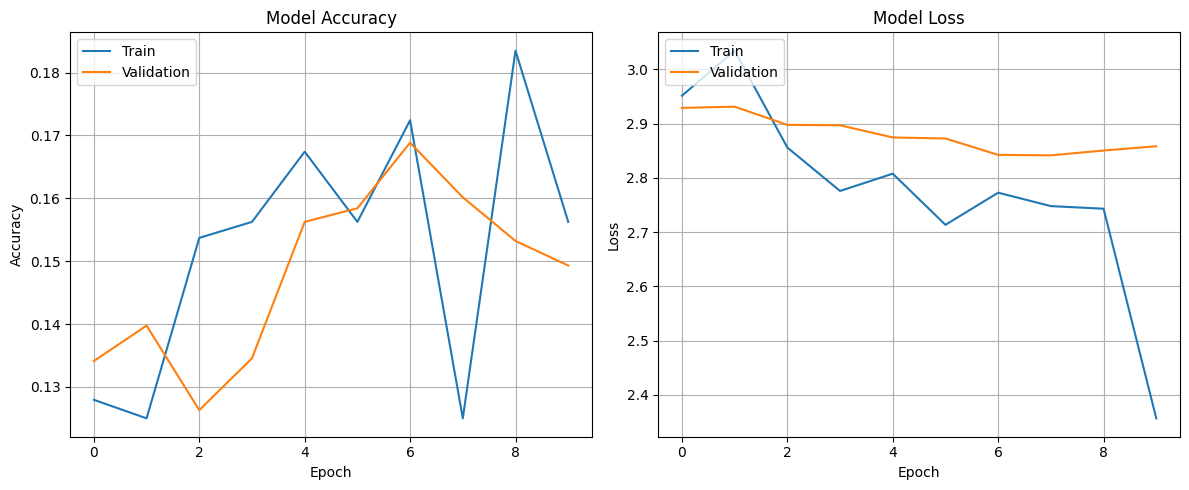

Training and Validation History plots displayed.


In [16]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Training and Validation History plots displayed.")

### Reading the Training Curves

*   **Accuracy plot**: ideally both curves climb together. A training accuracy that pulls well ahead of validation accuracy is the classic signature of **overfitting** — the model is starting to memorize training examples rather than learning generalizable patterns. If both curves are low and flat, that's **underfitting** — the model doesn't have enough capacity, or hasn't trained long enough, to fit the data at all.
*   **Loss plot**: the same logic in reverse — both curves should fall, and a growing gap between them (training loss dropping while validation loss flattens or rises) is the same overfitting signal.

These curves are how you decide whether to keep training, stop early, add regularization, or reach for a fundamentally different approach — not the final accuracy number alone. Keep this pattern in mind; we'll use it again to interpret the transfer learning results later.

In [17]:
print("Evaluating model on test data...")

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print("Model evaluation on test data complete.")

Evaluating model on test data...
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.1855 - loss: 2.7442

Test Loss: 2.7442
Test Accuracy: 0.1855
Model evaluation on test data complete.


### Reading the Test Set Result

This is the number that matters most — performance on data the model has never influenced any decision about, now that our validation and test sets are properly separated. Test accuracy tells you how often the model gets it right on unseen images; test loss tells you how confidently wrong it is on average.

Keep this number in mind as a baseline. The real value of a baseline isn't the number itself — it's having something concrete to measure every subsequent improvement against.

Making predictions on sample test images...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


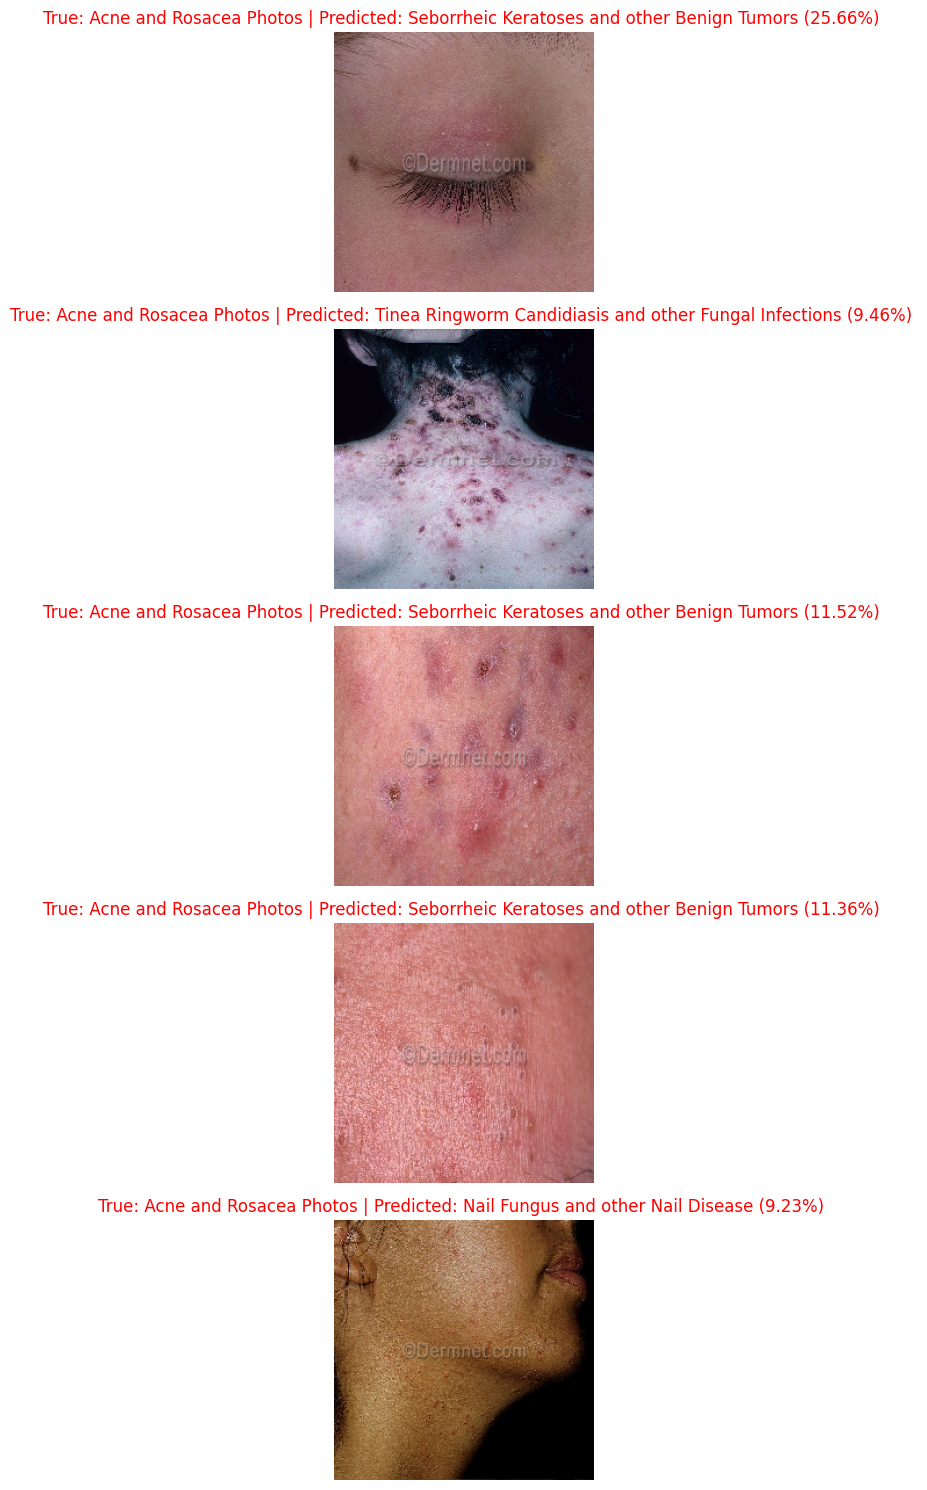

Sample predictions displayed.


In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_sample_images(generator, model, num_samples=5):
    # Get class labels from the generator
    labels = list(generator.class_indices.keys())

    plt.figure(figsize=(15, num_samples * 3))
    for i in range(num_samples):
        # Get a batch of images and labels from the generator
        img_batch, label_batch = generator[i]

        # Take the first image from the batch for prediction and visualization
        img_to_predict = img_batch[0]
        true_label_one_hot = label_batch[0]
        true_label_index = np.argmax(true_label_one_hot)
        true_label_name = labels[true_label_index]

        # Add batch dimension for prediction
        img_for_model = np.expand_dims(img_to_predict, axis=0)

        # Make prediction
        predictions = model.predict(img_for_model)
        predicted_class_index = np.argmax(predictions[0])
        predicted_class_name = labels[predicted_class_index]
        confidence = np.max(predictions[0]) * 100

        plt.subplot(num_samples, 1, i + 1)
        plt.imshow(img_to_predict) # ImageDataGenerator already rescaled
        title_color = 'green' if predicted_class_name == true_label_name else 'red'
        plt.title(f"True: {true_label_name} | Predicted: {predicted_class_name} ({confidence:.2f}%) ", color=title_color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Making predictions on sample test images...")
# Display predictions for a few sample images from the test set
predict_sample_images(test_generator, model, num_samples=5)
print("Sample predictions displayed.")

### Reading Individual Predictions

Aggregate metrics can hide a lot. Looking at specific predictions — right and wrong — does three things an accuracy number can't:

*   **Confirms correctness concretely**, on cases you can actually inspect.
*   **Surfaces failure patterns** — are the misclassifications between visually similar conditions? Between the minority classes we flagged earlier? That's actionable information a single number erases.
*   **Calibrates your trust** in the model's confidence scores — a model that's 98% confident and wrong is a different (and more concerning) problem than one that's 55% confident and wrong.

### Baseline Recap — And Why We're Not Done Yet

We now have an honest, properly-evaluated baseline: a simple CNN, trained from scratch, on correctly separated train/validation/test splits. That's a legitimate milestone, and it's worth pausing on what it does and doesn't tell us.

What it tells us: the fundamentals — data pipeline, architecture, training loop, evaluation — are all wired correctly.

What it doesn't tell us: whether we're anywhere near the best this dataset can support. A CNN trained from scratch on a dataset this size, with real class imbalance, is working at a real disadvantage compared to a model that starts from features already learned on millions of images. It's also being trained with a training loop that's missing infrastructure any production system would have — no early stopping, no handling for the class imbalance we identified earlier, and an off-by-a-partial-batch `steps_per_epoch` calculation.

That's the agenda for the rest of this notebook: take this baseline, diagnose its specific shortcomings, and systematically fix them — the way you would on a real project, not by guessing at a better architecture, but by addressing the concrete issues the data and the training run have already told us about.

## 6. From Baseline to Production: Transfer Learning & Fine-Tuning

To meaningfully improve on the baseline, we're making four changes, each addressing a specific, identifiable weakness rather than being a generic "try harder" tweak:

1.  **Correct `steps_per_epoch` and `validation_steps` calculation.** The baseline used floor division (`//`), which silently drops a partial final batch every epoch — meaning some training images are never seen. Switching to `math.ceil` ensures every image contributes.

2.  **Class weighting.** We identified real class imbalance during data exploration. Left unaddressed, a model naturally optimizes for the majority classes at the minority classes' expense — exactly the failure mode you don't want in a diagnostic-adjacent task. `class_weight` tells the loss function to penalize mistakes on under-represented classes more heavily.

3.  **Two-stage transfer learning: frozen base, then fine-tuning.** Training a CNN from scratch on a dataset this size is starting from zero. Instead, we'll start from **MobileNetV2**, pre-trained on ImageNet, and reuse its already-learned low- and mid-level visual features (edges, textures, shapes) — features that generalize well across almost any image classification task. We freeze that base first and train only a new classification head, then unfreeze the top of the base and fine-tune it at a very low learning rate so it adapts specifically to dermatological images without losing what it already knows.

4.  **Production-grade training callbacks.** The baseline trained for a fixed number of epochs with no safety net. We'll add `EarlyStopping` (stop once validation loss stops improving, and restore the best-performing weights — not necessarily the weights from the final epoch), `ReduceLROnPlateau` (automatically shrink the learning rate if progress stalls), and `ModelCheckpoint` (persist the best model to disk as we go, rather than only at the very end). This is standard infrastructure for any training run you'd actually trust — it protects you from both overfitting and wasted compute.

Let's implement these one at a time, starting with the data and training-loop fixes.

In [19]:
import math
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("Recalculating steps, preparing class weights, and defining training callbacks...")

# 1. Correct steps-per-epoch calculation, for train, validation, and test alike.
# This ensures all samples are used, including partial batches.
STEPS_PER_EPOCH = math.ceil(train_generator.samples / BATCH_SIZE)
VALIDATION_STEPS = math.ceil(val_generator.samples / BATCH_SIZE)
TEST_STEPS = math.ceil(test_generator.samples / BATCH_SIZE)

print(f"STEPS_PER_EPOCH (train): {STEPS_PER_EPOCH}")
print(f"VALIDATION_STEPS (held-out validation split): {VALIDATION_STEPS}")
print(f"TEST_STEPS (fully held-out test set): {TEST_STEPS}")

# 2. Class weights, computed from the TRAINING subset only.
class_labels = train_generator.classes
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights computed to counter the imbalance identified during data exploration.")

# 3. Callbacks shared by both transfer-learning training stages below.
MODEL_CHECKPOINT_PATH = 'best_dermnet_model.keras'

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        MODEL_CHECKPOINT_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Data preparation and training infrastructure ready.")

Recalculating steps, preparing class weights, and defining training callbacks...
STEPS_PER_EPOCH (train): 414
VALIDATION_STEPS (held-out validation split): 73
TEST_STEPS (fully held-out test set): 126
Class weights computed to counter the imbalance identified during data exploration.
Data preparation and training infrastructure ready.


### Key Takeaway: Correct Steps, Fair Weighting, and a Safety Net

The `math.ceil` fix guarantees every image in the dataset is actually seen each epoch — the earlier floor-division approach was quietly leaving a partial batch on the table every time.

`class_weight` is the more consequential change: by penalizing mistakes on minority classes more heavily, we're directly countering the imbalance we flagged during data exploration, which should show up as better recall on the rarer conditions — exactly the classes where being wrong matters most.

And the three callbacks now sit underneath every training run from here on: `EarlyStopping` protects us from overfitting past the point of diminishing returns (and hands back the *best* weights, not just the last ones), `ReduceLROnPlateau` gives the optimizer a chance to keep making progress once it plateaus, and `ModelCheckpoint` means we always have the best version of the model saved to disk, not just whatever happened to be in memory when a Colab session disconnects.

With that infrastructure in place, let's build the transfer learning model itself.

In [20]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

print("Defining Transfer Learning Model (MobileNetV2) for initial training with frozen base...")

# 1. Load the pre-trained MobileNetV2 model, without its top classification layer
base_model_tl = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                            include_top=False,
                            weights='imagenet')

# 2. Freeze the convolutional base to use its pre-trained weights as feature extractors
base_model_tl.trainable = False

# 3. Add our new classification layers on top of the base model
x = base_model_tl.output
x = GlobalAveragePooling2D()(x) # Convert features to a single vector per image
x = Dense(512, activation='relu')(x) # A new dense layer
x = Dropout(0.5)(x) # Dropout for regularization
predictions = Dense(num_classes, activation='softmax')(x) # One output unit per class, sized dynamically via num_classes

# 4. Construct the full model
transfer_model = Model(inputs=base_model_tl.input, outputs=predictions)

# 5. Compile the new model for the *frozen* stage
# We start with a slightly higher learning rate here as we are only training the top layers
transfer_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Display the model summary for our new transfer learning model
transfer_model.summary()

print("Transfer Learning Model (MobileNetV2 base) defined and compiled for frozen stage!")

Defining Transfer Learning Model (MobileNetV2) for initial training with frozen base...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,925,655 (11.16 MB)

 Trainable params: 667,671 (2.55 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Transfer Learning Model (MobileNetV2 base) defined and compiled for frozen stage!


### Key Takeaway: Why We Freeze the Base First

`base_model_tl.trainable = False` is the important line here. MobileNetV2's convolutional layers already encode genuinely useful, general-purpose visual features learned from over a million ImageNet images — features good at detecting edges, textures, and shapes regardless of domain. Freezing them protects that knowledge from being disrupted by large, noisy gradient updates early in training, when our new, randomly-initialized classification head is still learning and would otherwise push destructive updates back through the entire network.

We train only the new head first, let it stabilize, and only then consider adjusting the base itself — that's the fine-tuning stage coming up next.

In [21]:
print("Starting Stage 1 Training: Frozen Base Model...")

EPOCHS_FROZEN = 20  # Generous ceiling -- EarlyStopping will cut this short once val_loss plateaus

# Train the transfer learning model with frozen base and class weights
history_frozen = transfer_model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS_FROZEN,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,
    class_weight=class_weights, # Apply the calculated class weights
    callbacks=callbacks
)

print("Stage 1 Training: Frozen Base Model complete!")

Starting Stage 1 Training: Frozen Base Model...
Epoch 1/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.1298 - loss: 3.1067
Epoch 1: val_loss improved from None to 2.91106, saving model to best_dermnet_model.keras

Epoch 1: finished saving model to best_dermnet_model.keras
414/414 ━━━━━━━━━━━━━━━━━━━━ 244s 543ms/step - accuracy: 0.1610 - loss: 2.9055 - val_accuracy: 0.1670 - val_loss: 2.9111 - learning_rate: 0.0010
Epoch 2/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.2027 - loss: 2.6783
Epoch 2: val_loss improved from 2.91106 to 2.83274, saving model to best_dermnet_model.keras

Epoch 2: finished saving model to best_dermnet_model.keras
414/414 ━━━━━━━━━━━━━━━━━━━━ 196s 474ms/step - accuracy: 0.2037 - loss: 2.6813 - val_accuracy: 0.1837 - val_loss: 2.8327 - learning_rate: 0.0010
Epoch 3/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.2139 - loss: 2.6030
Epoch 3: val_loss did not improve from 2.83274
414/414 ━━━━━━━━━━━━━━━━━━━━ 195s 470ms/step - a

### Reading Stage 1

You should see a sharp improvement over the from-scratch baseline, often within just the first few epochs — that's transfer learning paying off immediately, since the model isn't learning to see from nothing. If `EarlyStopping` triggered before reaching `EPOCHS_FROZEN`, that's not a failure — it's the callback doing exactly its job, stopping once validation loss stopped improving and handing back the best weights seen so far rather than whatever the final epoch happened to produce.

This stage only trained the new classification head. Next, we let the base model itself adapt slightly to dermatological images specifically.

In [22]:
print("Starting Stage 2 Training: Fine-tuning Base Model...")

# Unfreeze the base model so its weights can be updated during this stage
base_model_tl.trainable = True

# Any change to a layer's `trainable` attribute requires recompiling the model.
# A very low learning rate is essential here -- we're making small corrective
# adjustments to already-good pre-trained weights, not learning from scratch.
transfer_model.compile(optimizer=Adam(learning_rate=0.00001), # Very low learning rate
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()

EPOCHS_FINE_TUNE = 20  # Again, EarlyStopping governs the actual stopping point

history_fine_tune = transfer_model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS_FINE_TUNE,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,
    class_weight=class_weights, # Continue applying class weights
    callbacks=callbacks
)

print("Stage 2 Training: Fine-tuning Base Model complete!")

Starting Stage 2 Training: Fine-tuning Base Model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,925,655 (11.16 MB)

 Trainable params: 2,891,543 (11.03 MB)

 Non-trainable params: 34,112 (133.25 KB)

Epoch 1/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.1069 - loss: 3.1207
Epoch 1: val_loss did not improve from 2.79029
414/414 ━━━━━━━━━━━━━━━━━━━━ 302s 595ms/step - accuracy: 0.1352 - loss: 2.9232 - val_accuracy: 0.1751 - val_loss: 3.0697 - learning_rate: 1.0000e-05
Epoch 2/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.1819 - loss: 2.7291
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 2: val_loss did not improve from 2.79029
414/414 ━━━━━━━━━━━━━━━━━━━━ 205s 496ms/step - accuracy: 0.1930 - loss: 2.6700 - val_accuracy: 0.1592 - val_loss: 3.1426 - learning_rate: 1.0000e-05
Epoch 3/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.2205 - loss: 2.6065
Epoch 3: val_loss did not improve from 2.79029
414/414 ━━━━━━━━━━━━━━━━━━━━ 265s 504ms/step - accuracy: 0.2185 - loss: 2.6007 - val_accuracy: 0.1540 - val_loss: 3.0554 - learning_rate: 2.0000e-06
Epoch 4/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.22

### Key Takeaway: Fine-Tuning, Carefully

Setting `base_model_tl.trainable = True` and recompiling with a learning rate roughly 100x smaller than before is the core of fine-tuning. **Why so low?** A large learning rate here would overwrite the pre-trained weights with large, noisy updates driven by our comparatively small dataset — destroying the very features that made transfer learning worth doing in the first place. A tiny learning rate lets the base model make small, targeted adjustments toward dermatological images specifically, while retaining almost everything it already knew.

This frozen-then-fine-tuned pattern is standard practice in transfer learning precisely because it balances two competing goals: benefiting from large-scale pre-training, while still adapting to a new, more specific domain. With training complete, let's look at the combined picture across both stages, then get a rigorous final evaluation.

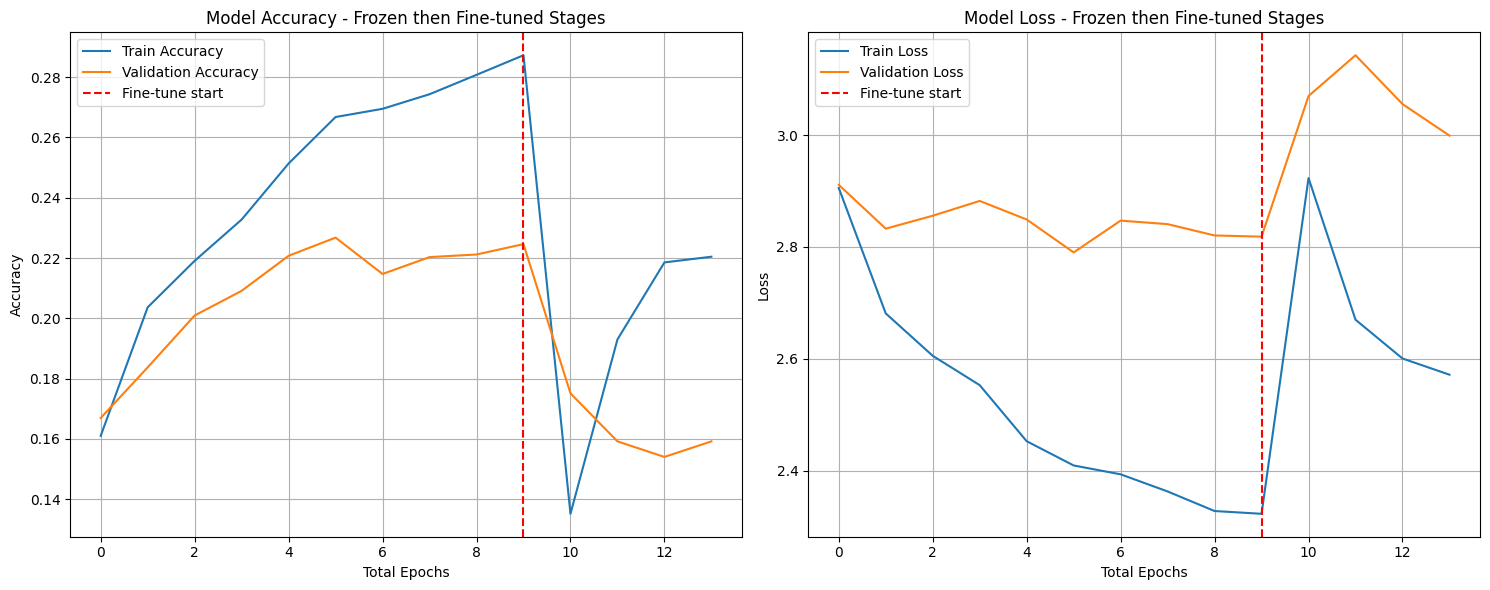

Combined Training and Validation History plots displayed.


In [23]:
import matplotlib.pyplot as plt

# Combine histories for plotting
acc_frozen = history_frozen.history['accuracy']
val_acc_frozen = history_frozen.history['val_accuracy']
loss_frozen = history_frozen.history['loss']
val_loss_frozen = history_frozen.history['val_loss']

acc_fine_tune = history_fine_tune.history['accuracy']
val_acc_fine_tune = history_fine_tune.history['val_accuracy']
loss_fine_tune = history_fine_tune.history['loss']
val_loss_fine_tune = history_fine_tune.history['val_loss']

total_acc = acc_frozen + acc_fine_tune
total_val_acc = val_acc_frozen + val_acc_fine_tune
total_loss = loss_frozen + loss_fine_tune
total_val_loss = val_loss_frozen + val_loss_fine_tune

# Plot training & validation accuracy values
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(total_acc, label='Train Accuracy')
plt.plot(total_val_acc, label='Validation Accuracy')
plt.axvline(x=len(acc_frozen)-1, color='r', linestyle='--', label='Fine-tune start') # Mark fine-tuning start
plt.title('Model Accuracy - Frozen then Fine-tuned Stages')
plt.ylabel('Accuracy')
plt.xlabel('Total Epochs')
plt.legend(loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(total_loss, label='Train Loss')
plt.plot(total_val_loss, label='Validation Loss')
plt.axvline(x=len(loss_frozen)-1, color='r', linestyle='--', label='Fine-tune start') # Mark fine-tuning start
plt.title('Model Loss - Frozen then Fine-tuned Stages')
plt.ylabel('Loss')
plt.xlabel('Total Epochs')
plt.legend(loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Combined Training and Validation History plots displayed.")

### Reading the Combined Training History

A few patterns to look for across the full two-stage run:

*   **A steep early climb** during the frozen stage — the clearest visual evidence of transfer learning's head start.
*   **The transition at the fine-tuning mark** (the dashed line): ideally, validation performance continues to improve, even if more slowly — evidence the base model's small adjustments are genuinely helping rather than just adding noise.
*   **Divergence after fine-tuning begins** — if training accuracy keeps climbing while validation stalls or drops, that's overfitting creeping in during fine-tuning specifically, and it's a signal to unfreeze fewer layers, lower the learning rate further, or lean more heavily on `EarlyStopping` and `ModelCheckpoint` to fall back on an earlier, better checkpoint (which, thanks to the callbacks configured above, we already are).

*Note: since `EarlyStopping` may have ended either stage before its full epoch budget, the dashed line marks where the frozen stage's history actually ended, not necessarily `EPOCHS_FROZEN`.*

Time for the number that matters most: a single, honest evaluation on the test set we've kept fully separate this entire time.

In [24]:
from sklearn.metrics import fbeta_score, recall_score, precision_score, accuracy_score, classification_report
import numpy as np

print("Evaluating final fine-tuned model on the held-out test set...")

# Reset the test generator to ensure a clean evaluation
test_generator.reset()

# Get predictions from the fine-tuned model -- TEST_STEPS, not VALIDATION_STEPS,
# since this is the one moment we finally touch the fully held-out test set.
predictions_raw = transfer_model.predict(test_generator, steps=TEST_STEPS)

# Get true labels
true_labels = test_generator.classes

# Convert raw predictions (probabilities) to predicted class indices
predicted_labels = np.argmax(predictions_raw, axis=1)

# Guard against any length mismatch from the final partial batch
if len(predicted_labels) < len(true_labels):
    true_labels = true_labels[:len(predicted_labels)]

# Calculate overall accuracy
final_accuracy = accuracy_score(true_labels, predicted_labels)
print(f"\nTest Accuracy (Fine-tuned Model): {final_accuracy:.4f}")

# Calculate F2 score (and other relevant metrics)
# 'weighted' average is good for imbalanced datasets, considering support for each class.
final_f2_score = fbeta_score(true_labels, predicted_labels, beta=2, average='weighted')
final_recall = recall_score(true_labels, predicted_labels, average='weighted')
final_precision = precision_score(true_labels, predicted_labels, average='weighted', zero_division=0)

print(f"Test Precision (Weighted): {final_precision:.4f}")
print(f"Test Recall (Weighted): {final_recall:.4f}")
print(f"Test F2 Score (Weighted): {final_f2_score:.4f}")

# For a more detailed breakdown, including per-class metrics:
print("\nClassification Report (per class metrics):")
class_names = list(test_generator.class_indices.keys())
print(classification_report(true_labels, predicted_labels, target_names=class_names, zero_division=0))

print("Final model evaluation complete -- this test set was never used in any training decision above.")

Evaluating final fine-tuned model on the held-out test set...
126/126 ━━━━━━━━━━━━━━━━━━━━ 31s 208ms/step

Test Accuracy (Fine-tuned Model): 0.2109
Test Precision (Weighted): 0.3095
Test Recall (Weighted): 0.2109
Test F2 Score (Weighted): 0.1946

Classification Report (per class metrics):
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.49      0.23      0.31       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.57      0.06      0.10       288
                                          Atopic Dermatitis Photos       0.15      0.31      0.20       123
                                            Bullous Disease Photos       0.17      0.04      0.07       113
                Cellulitis Impetigo and other Bacterial Infections       0.06      0.07      0.07        73
                                                     Eczema P

### Reading the Final Result

This is the number we can actually trust: a test set that was never used to pick a checkpoint, tune a learning rate, or decide when to stop training.

*   **F2 score, weighted**, is our headline metric because it weights recall more heavily than precision — appropriate here, since a missed condition (false negative) is generally more costly than a false alarm in a screening context. A high F2 score means we're doing a good job of catching true positives, even at some cost in precision.
*   **The classification report** breaks precision, recall, and F1 down per class — this is where imbalance-related weaknesses would still show up even after class weighting, and it's worth scanning specifically for the minority classes we identified early on.

One aggregate score, though, still hides *which* classes get confused with which — and for a multi-class clinical problem, that pattern usually matters more than the headline number. Let's look at it directly.

## 7. From Notebook to Practice: Diagnostics, Saving, and Deploying Responsibly

A trained model with a good F2 score isn't a finished product — it's a checkpoint. This last section covers three things any real project needs next: understanding *where* the model actually fails (not just how often), persisting the model properly, and being explicit about what stands between this notebook and something safe to deploy.

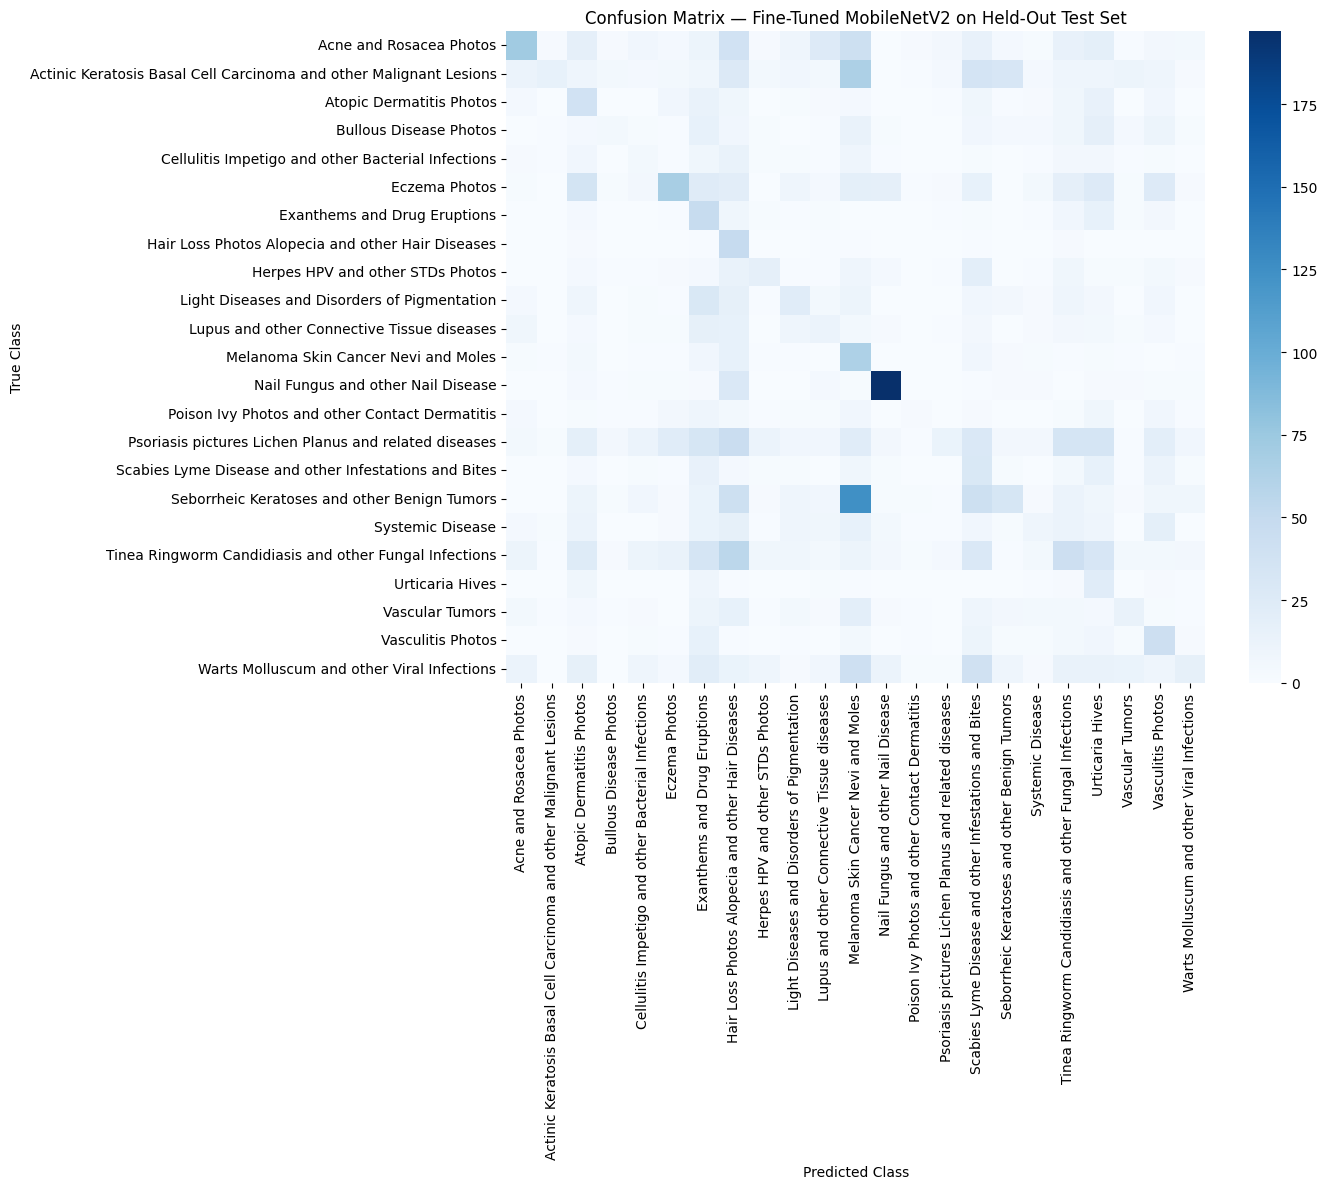

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar=True)
plt.title('Confusion Matrix — Fine-Tuned MobileNetV2 on Held-Out Test Set')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Reading the Confusion Matrix

A strong diagonal is what you want — it means predictions mostly land on the correct class. What's more informative than the diagonal, though, is where the *off*-diagonal mass concentrates. Bright cells away from the diagonal tell you specifically which conditions the model confuses with each other — often conditions that are visually similar even to a trained eye, which is valuable, actionable information a single F2 score can't give you.

In a real deployment, this is exactly the analysis you'd bring back to a clinical collaborator: not "the model is 80% accurate," but "the model is reliable on conditions A and B, and specifically confuses C with D — here's why that might be, and here's what additional data or model changes might address it." That's a materially more useful conversation, and it's the kind of diagnostic work that separates a demo from something a domain expert can actually act on.

In [26]:
MODEL_SAVE_PATH = 'dermnet_mobilenetv2_finetuned.keras'
transfer_model.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

# Note: this saves into the Colab runtime's local (ephemeral) storage -- it
# disappears when the session disconnects. In a real project, the next step
# here would be pushing this artifact to persistent storage (e.g. a cloud
# bucket or a model registry like MLflow or Vertex AI Model Registry), tagged
# with the training run's metrics, data version, and hyperparameters, so it's
# reproducible and auditable -- not just a file sitting in a notebook's
# temporary disk.

Model saved to: dermnet_mobilenetv2_finetuned.keras


### Masterclass Conclusion

Let's step back and look at the full arc of what we built:

1.  **Acquired and honestly split the data** — including fixing a subtle but consequential bug: validation and test sets that were never allowed to bleed into each other.
2.  **Explored the data critically** — surfacing class imbalance and, just as importantly, the ethical dimension of working with medical imaging data.
3.  **Built the fundamentals from scratch** — convolution, padding, stride, and pooling, computed by hand before trusting a framework to do it for us.
4.  **Trained an honest baseline CNN** — a deliberately simple model, evaluated correctly, to give every later improvement something real to be measured against.
5.  **Diagnosed the baseline's specific weaknesses and fixed them one at a time** — correct batch accounting, class weighting, transfer learning, fine-tuning, and production-grade training callbacks — rather than reaching for a bigger model and hoping.
6.  **Evaluated rigorously** — a weighted F2 score and full classification report on a genuinely untouched test set, plus a confusion matrix to see exactly where the remaining errors concentrate.

**And one thing I want to leave you with, because it's the part most tutorials skip entirely:** this notebook produces a strong prototype, not a deployable diagnostic tool. Before anything built this way could responsibly inform a real skin condition assessment, it would need validation on a larger, demographically representative, prospectively collected dataset; review and sign-off from dermatology clinicians; documented performance across skin tones and imaging conditions; and, in most jurisdictions, formal regulatory clearance as a medical device. None of that is a footnote — it's the majority of the actual work in taking a model like this from a notebook to something that helps real patients safely.

That gap — between "the model scores well" and "the model is safe and fair to deploy" — is exactly the judgment I want this masterclass to leave you with, alongside the technical mechanics. Take this notebook, adapt the patterns to your own datasets, and keep asking both questions every time: *does it work*, and *should it be trusted*.

Well done, team.